# Exercise 5

In [105]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math

## Part 1

Estimate the integral 

$ \int_0^1 e^x dx $

by simulation using the crude Monte Carlo estimator.   
Use, for example, an estimator based on 100 samples.   
Present the result as both a point estimate and a confidence interval.

Analytical solution:

$ \theta = \int_0^1 e^x dx = e-1 \approx 1.7183 $

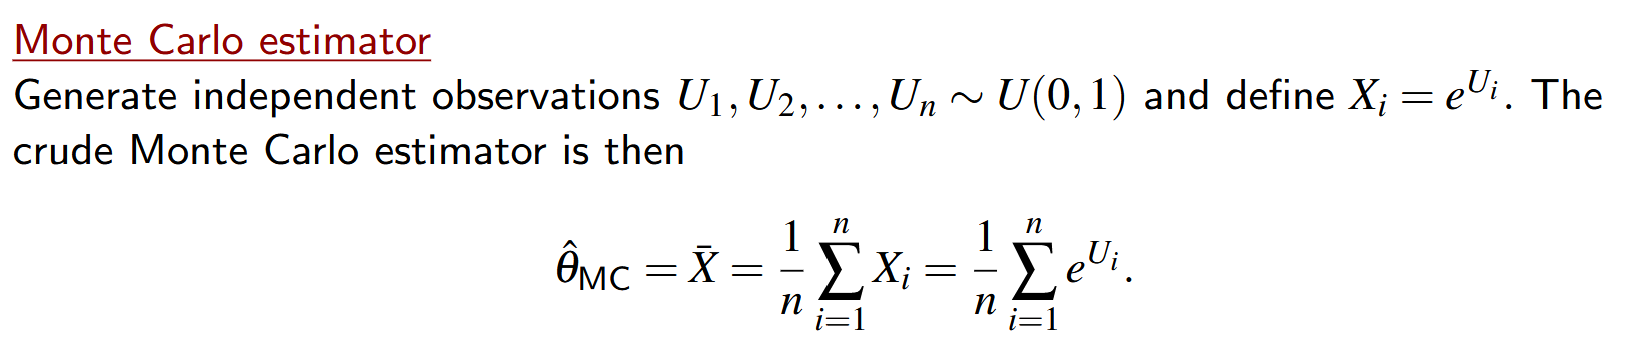

In [150]:
#Function for crude MC estimator
def MC_crude_est(n_samples=10, n_subsamples=100):
    """
    Crude monte carlo estimator of integral of e^x from x=0 to x=1, (X_i = e^(U_i))
    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []

    #loop over samples
    for i in range(n_samples):

        # Draw samples from uni. dist.
        U = sp.stats.uniform.rvs(size=n_subsamples)

        # compute integral values (X_i, the summand e^(U_i))
        X = np.exp(U)

        #compute variance of Y
        var_Y = np.var(X)

        # Compute MC estimator
        thetaH_MC = (1/n_subsamples) * np.sum(X) 

        # Store result
        results.append(thetaH_MC)
        var_Y_list.append(var_Y)
    
    #Take mean of all variances
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of all variances: {var_Y_mean:.3g}")


    return np.array(results)


In [151]:
#Function for confidence interval (reused)
def confidence_interval(estimator, alpha=0.05):

    #sample size
    n=len(estimator)

    #estimate mean
    mean = np.mean(estimator)
    var = np.var(estimator, ddof=1)
    stddev = np.sqrt(var)

    #Degrees of freedom
    df=n-1

    #computing test statistic
    t_lower = sp.stats.t.ppf(q=alpha/2, df=df)
    t_upper = sp.stats.t.ppf(q=1-alpha/2, df=df)

    conf_lower = mean + stddev/np.sqrt(n) * t_lower
    conf_upper = mean + stddev/np.sqrt(n) * t_upper

    return mean, conf_lower, conf_upper

In [153]:
#Compute result

n_samples = 10
n_subsamples = 100
ex_val = np.exp(1)-1
thetaH_MCs = MC_crude_est(n_samples=n_samples, n_subsamples=n_subsamples)

#Compute mean and conf. interval
thetaH_MC_mean, thetaH_MC_LCI, thetaH_MC_UCI = confidence_interval(estimator=thetaH_MCs, alpha=0.05)


print(f"results ( for n_samples: {n_samples}, n_subsamples: {n_subsamples}):")
print(f"thetaH_MC mean: {thetaH_MC_mean:.4f}")
print(f"confindence interval: {thetaH_MC_LCI:.4f} {thetaH_MC_UCI:.4f}")
print(f"CI width (precision measure): {thetaH_MC_UCI-thetaH_MC_LCI:.3e}")
print(f"true val: {ex_val:.4f}")

mean of all variances: 0.243
results ( for n_samples: 10, n_subsamples: 100):
thetaH_MC mean: 1.7035
confindence interval: 1.6625 1.7445
CI width (precision measure): 8.196e-02
true val: 1.7183


## Part 2

Estimate the integral 

$ \int_0^1 e^x dx $

using antithetic variables and comparable computational resources

In [154]:
def MC_AV_est(n_samples=10, n_subsamples=100):
    """
    Antithetic variable monte carlo estimator
    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []

    #loop over samples
    for i in range(n_samples):

        #Draw samples from uni. dist.
        U = sp.stats.uniform.rvs(size=n_subsamples)

        #Create the antithetic variables 
        UA = 1-U 

        #compute summand of estimator: (Y = e^(U_i) + e^UA_i)/2
        Y = (np.exp(U) + np.exp(UA)) / 2

        #compute variance of Y
        var_Y = np.var(Y)

        #Compute the AV estimator
        thetaH_AV = (1/n_subsamples) * np.sum(Y) 

        # Store result
        results.append(thetaH_AV)
        var_Y_list.append(var_Y)
    
    #Take mean of all variances
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of all variances: {var_Y_mean:.3g}")

    return np.array(results)

In [158]:
#Compute result

n_samples = 10
n_subsamples = 100
ex_val = np.exp(1)-1 
thetaH_AVs = MC_AV_est(n_samples=n_samples, n_subsamples=n_subsamples)

#Compute mean and conf. interval
thetaH_AV_mean, thetaH_AV_LCI, thetaH_AV_UCI = confidence_interval(estimator=thetaH_AVs, alpha=0.05)


print(f"results antithetic variables ( for n_samples: {n_samples}, n_subsamples: {n_subsamples}):")

print(f"thetaH_AV mean: {thetaH_AV_mean:.4f}")
print(f"confindence interval: {thetaH_AV_LCI:.4f} {thetaH_AV_UCI:.4f}")
print(f"CI width (precision measure): {thetaH_AV_UCI-thetaH_AV_LCI:.3e}")
print(f"true val: {ex_val:.4f}")

mean of all variances: 0.00391
results antithetic variables ( for n_samples: 10, n_subsamples: 100):
thetaH_AV mean: 1.7200
confindence interval: 1.7157 1.7242
CI width (precision measure): 8.454e-03
true val: 1.7183


## Part 3

Estimate the integral 

$ \int_0^1 e^x dx $

using a control variate and comparable computational resources

We use a $Z_i \sim U(0,1)$  (a uniformly distributed variable) as control variate

In [159]:
def MC_CV_est(n_samples=10, n_subsamples=100):
    """
    Control variates monte carlo estimator
    Using Z_i ~ uniform(0,1) as control variate
    and X_i ~ e^(U_i)  where  U_i ~ uniform(0,1)
    to compute 
    Y_i = X_i + c(Z_i - mu_Z)     (mu is mean)

    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []

    #loop over samples
    for i in range(n_samples):

        # Draw samples from uni. dist. 
        U = sp.stats.uniform.rvs(size=n_subsamples)

        # (also used as control variate, Z)
        Z = np.copy(U)

        # compute X_i values (the summand e^(U_i))
        X = np.exp(U)

        ### Computing c:
        # Compute covariance matrix of X_i and Z_i (size 2 x 2)
        cov_mat = np.cov(X, Z)
        #Extract cov(X,U) from covariance matrix as off diagonal
        cov_XZ = cov_mat[0,1]
        #Extract var(U) from covariance matrix as second diagonal element
        var_Z = cov_mat[1,1]
        #Calculate c
        c = -cov_XZ / var_Z

        ### Estimate mu_Z
        mu_Z = np.mean(Z)

        # Compute Y
        Y = X + c*(Z-mu_Z)

        #compute variance of Y
        var_Y = np.var(Y)

        #Compute the AV estimator
        thetaH_CV = (1/n_subsamples) * np.sum(Y) 

        # Store result
        results.append(thetaH_CV)
        var_Y_list.append(var_Y)

    #Take mean of all variances
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of all variances: {var_Y_mean:.3g}")

    return np.array(results)

In [160]:
#Compute result

n_samples = 10
n_subsamples = 100
ex_val = np.exp(1)-1 
thetaH_CVs = MC_CV_est(n_samples=n_samples, n_subsamples=n_subsamples)

#Compute mean and conf. interval
thetaH_CV_mean, thetaH_CV_LCI, thetaH_CV_UCI = confidence_interval(estimator=thetaH_CVs, alpha=0.05)


print(f"results ( for n_samples: {n_samples}, n_subsamples: {n_subsamples}):")

print(f"thetaH_CV mean: {thetaH_CV_mean:.4f}")
print(f"confindence interval: {thetaH_CV_LCI:.4f} {thetaH_CV_UCI:.4f}")
print(f"CI width (precision measure): {thetaH_CV_UCI-thetaH_CV_LCI:.3e}")
print(f"true val: {ex_val:.4f}")

mean of all variances: 0.00388
results ( for n_samples: 10, n_subsamples: 100):
thetaH_CV mean: 1.7035
confindence interval: 1.6625 1.7445
CI width (precision measure): 8.196e-02
true val: 1.7183


## Part 4 (not finished)

Estimate the integral 

$ \int_0^1 e^x dx $

using stratified sampling and comparable computational resources

In [ ]:
#Function for stratified sampling MC estimator
def MC_SS_est(n_samples=100, n_subsamples=1000):
    """
    Stratified sampling monte carlo estimator of integral of e^x from x=0 to x=1, (X_i = e^(U_i))
    Using 10 strata

    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []
    
    #loop over samples
    for i in range(n_samples):

        # Draw samples from uni. dist.
        U = sp.stats.uniform.rvs(size=n_subsamples)

        # compute integral values (X_i, the summand e^(U_i))
        X = np.exp(U)

        #compute variance of Y
        var_Y = np.var(X)

        # Compute MC estimator
        thetaH_MC = (1/n_subsamples) * np.sum(X) 

        # Store result
        results.append(thetaH_MC)
        var_Y_list.append(var_Y)
    
    #Take mean of all variances
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of all variances: {var_Y_mean:.3g}")


    return np.array(results)


## Part 7 

Let $Z ∼ N(0, 1)$.   
Estimate $P(Z > a)$ using the crude Monte Carlo estimator.   

Then apply importance sampling using a normal distribution with mean a and variance $\sigma^2$

- Start with $\sigma^2 = 1$.
- Experiment with different values of a (e.g., a = 2 and a = 4).
- Experiment with different sample sizes.
- If time permits, investigate other values of $\sigma^2$.

Finally, discuss the efficiency of the methods

In [ ]:
### Estimating P(z>a) using crude MC estimator
#Function for crude MC estimator for normal distribution
def MC_crude_est_normalTail(n_samples=10, n_subsamples=100, a=2):
    """
    Crude monte carlo estimator of P(Z>a),   (will be called Y)
    where Z ~ N(0,1)
    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
        a (float):                  x-val above which tail fraction is computed
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []

    #loop over samples
    for i in range(n_samples):

        # Draw samples from normal dist.
        Z = sp.stats.norm.rvs(size=n_subsamples)

        #Compute P(Z>a)
        # Compute MC estimator
        Y = np.size(Z[Z>a]) / n_subsamples

        # Store result
        results.append(Y)
    
    #Take variance of resutls
    var_Y = np.var(results)
    print(f"variance of estimates (a={a}): {var_Y:.3g}")

    return np.array(results)

In [280]:
#Compute result a=2
n_samples = 10
n_subsamples = 1000
a=2
ex_val = 1 - sp.stats.norm.cdf(x=a)

thetaH_CVs = MC_crude_est_normalTail(n_samples=n_samples, n_subsamples=n_subsamples, a=a)

#Compute mean and conf. interval
thetaH_CV_mean, thetaH_CV_LCI, thetaH_CV_UCI = confidence_interval(estimator=thetaH_CVs, alpha=0.05)

print(f"results (for n_samples: {n_samples}, n_subsamples: {n_subsamples}, a={a}):")

print(f"thetaH_CV mean: {thetaH_CV_mean:.2e}")
print(f"confindence interval: {thetaH_CV_LCI:.2e} {thetaH_CV_UCI:.2e}")
print(f"CI width (precision measure): {thetaH_CV_UCI-thetaH_CV_LCI:.3e}")
print(f"true val: {ex_val:.2e}")

variance of estimates (a=2): 2.18e-05
results (for n_samples: 10, n_subsamples: 1000, a=2):
thetaH_CV mean: 2.37e-02
confindence interval: 2.02e-02 2.72e-02
CI width (precision measure): 7.043e-03
true val: 2.28e-02


In [279]:
#Compute result a=4
n_samples = 10
n_subsamples = 1000
a=4
ex_val = 1 - sp.stats.norm.cdf(x=a)

thetaH_CVs = MC_crude_est_normalTail(n_samples=n_samples, n_subsamples=n_subsamples, a=a)

#Compute mean and conf. interval
thetaH_CV_mean, thetaH_CV_LCI, thetaH_CV_UCI = confidence_interval(estimator=thetaH_CVs, alpha=0.05)

print(f"results (for n_samples: {n_samples}, n_subsamples: {n_subsamples}, a={a}):")

print(f"thetaH_CV mean: {thetaH_CV_mean:.2e}")
print(f"confindence interval: {thetaH_CV_LCI:.4f} {thetaH_CV_UCI:.2e}")
print(f"CI width (precision measure): {thetaH_CV_UCI-thetaH_CV_LCI:.3e}")
print(f"true val: {ex_val:.2e}")

variance of estimates (a=4): 0
results (for n_samples: 10, n_subsamples: 1000, a=4):
thetaH_CV mean: 0.00e+00
confindence interval: 0.0000 0.00e+00
CI width (precision measure): 0.000e+00
true val: 3.17e-05


In [283]:
def MC_importance_est_normalTail(n_samples=10, n_subsamples=100, a=2, sigma2=1):
    """
    Importance sampling estimator of P(Z>a),   (will be called Y)
    where Z ~ N(0,1)
    So 
    f(x) = pdf of N(0,1)
    g(x) = pfd of N(a,1)
    h(x) = 1(z>a)   (indocator)
    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
        a (float):                  x-val above which tail fraction is computed
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []

    #loop over samples
    for i in range(n_samples):

        # Draw samples from the importance fucntion dist g (with mean = a, sigma2 = 1).
        Y = sp.stats.norm.rvs(loc=a, scale=sigma2, size=n_subsamples)

        # Compute quotient f(Y)/g(Y) of prob dens function of true dist over importance func for each var
        f_Y = sp.stats.norm.pdf(x=Y, loc=0, scale=1)
        g_Y = sp.stats.norm.pdf(x=Y, loc=a, scale=sigma2)
        quot_fg = f_Y/g_Y

        #Compute P(z>a) (same as indicator function) 
        h_Y = np.array([1 if x>a else 0 for x in Y])

        #Compute summand of estimator
        Y = h_Y*quot_fg

        #compute variance of summand
        var_Y = np.var(Y)

        #Compute estimator as mean
        thetaH_IS = (1/n_subsamples)*np.sum(Y)

        # Store result
        results.append(thetaH_IS)
        var_Y_list.append(var_Y)
    
    #Take variance of resutls
    var_res = np.var(results)
    #Take mean of variance of summands, Y
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of variance of summands (a={a}): {var_Y_mean:.3g}")

    return np.array(results)

In [284]:
# Apply function

#Compute result a=2
n_samples = 10
n_subsamples = 1000
a=2
ex_val = 1 - sp.stats.norm.cdf(x=a)

thetaH_ISs = MC_importance_est_normalTail(n_samples=n_samples, n_subsamples=n_subsamples, a=a, sigma2=1)

#Compute mean and conf. interval
thetaH_IS_mean, thetaH_IS_LCI, thetaH_IS_UCI = confidence_interval(estimator=thetaH_ISs, alpha=0.05)

print(f"results (for n_samples: {n_samples}, n_subsamples: {n_subsamples}, a={a}):")

print(f"thetaH_IS mean: {thetaH_IS_mean:.2e}")
print(f"confindence interval: {thetaH_CV_LCI:.2e} {thetaH_IS_UCI:.2e}")
print(f"CI width (precision measure): {thetaH_IS_UCI-thetaH_IS_LCI:.3e}")
print(f"true val: {ex_val:.2e}")

mean of variance of summands (a=2): 0.00121
results (for n_samples: 10, n_subsamples: 1000, a=2):
thetaH_IS mean: 2.28e-02
confindence interval: 2.02e-02 2.34e-02
CI width (precision measure): 1.311e-03
true val: 2.28e-02


In [278]:
# Apply function

#Compute result a=4
n_samples = 10
n_subsamples = 1000
a=4
ex_val = 1 - sp.stats.norm.cdf(x=a)

thetaH_ISs = MC_importance_est_normalTail(n_samples=n_samples, n_subsamples=n_subsamples, a=a, sigma2=1)

#Compute mean and conf. interval
thetaH_IS_mean, thetaH_IS_LCI, thetaH_IS_UCI = confidence_interval(estimator=thetaH_ISs, alpha=0.05)

print(f"results (for n_samples: {n_samples}, n_subsamples: {n_subsamples}, a={a}):")

print(f"thetaH_IS mean: {thetaH_IS_mean:.2e}")
print(f"confindence interval: {thetaH_CV_LCI:.2e} {thetaH_IS_UCI:.2e}")
print(f"CI width (precision measure): {thetaH_IS_UCI-thetaH_IS_LCI:.3e}")
print(f"true val: {ex_val:.2e}")

variance of estimates (a=4): 2.92e-12
results (for n_samples: 10, n_subsamples: 1000, a=4):
thetaH_IS mean: 3.17e-05
confindence interval: 0.00e+00 3.30e-05
CI width (precision measure): 2.575e-06
true val: 3.17e-05


## Part 8 (not done)

Use importance sampling with 
$$g(x) = \lambda e^{-\lambda x}$$

to estimate    

$\int_0^1 e^x dx$ 

Try to identify the optimal value of $\lambda$ by analysing the variance of   
$$\frac{h(X) f(X)}{g(X)}$$
and verify your conclusions through simulation 

In [ ]:
#Produce function that samples variables 

def MC_importance_est_integral(n_samples=10, n_subsamples=100, lamb=1):
    """
    Importance sampling estimator of int(e^x),   
    
    So 
    f(x) = pdf of uniform(0,1)
    g(x) = pfd of exp(lamd)
    h(x) = exp^x
    input:
        n_samples (int):            sample size (how many times do we estimate thetaH_MC)
        n_subsamples (int):         sub samples size (for each sample, how many RVs do we use in order to compute mean)
        lambda (float):             parameter for importance sampling function
    output:
        (list)                      Crude MC estimators of integral of e^x from x=0 to x=1 
    """

    #Set random seed
    np.random.seed(seed=42)

    #Initialise results
    results = []
    var_Y_list = []

    #loop over samples
    for i in range(n_samples):

        # Draw samples from the importance fucntion dist g (with mean = a, sigma2 = 1).
        Y = sp.stats.norm.rvs(loc=a, scale=sigma2, size=n_subsamples)

        # Compute quotient f(Y)/g(Y) of prob dens function of true dist over importance func for each var
        f_Y = sp.stats.norm.pdf(x=Y, loc=0, scale=1)
        g_Y = sp.stats.norm.pdf(x=Y, loc=a, scale=sigma2)
        quot_fg = f_Y/g_Y

        #Compute P(z>a) (same as indicator function) 
        h_Y = np.array([1 if x>a else 0 for x in Y])

        #Compute summand of estimator
        Y = h_Y*quot_fg

        #compute variance of summand
        var_Y = np.var(Y)

        #Compute estimator as mean
        thetaH_IS = (1/n_subsamples)*np.sum(Y)

        # Store result
        results.append(thetaH_IS)
        var_Y_list.append(var_Y)
    
    #Take variance of resutls
    var_res = np.var(results)
    #Take mean of variance of summands, Y
    var_Y_mean = np.mean(var_Y_list)
    print(f"mean of variance of summands (a={a}): {var_Y_mean:.3g}")

    return np.array(results)